## Detecting biases

In [1]:
# required modules (under Anaconda use: > conda install -c conda-forge <package>)
if False: # (skip if already installed)
    !pip install lark-parser
    !pip install linear-tree
    !pip install pydot
    !pip install pydotplus
    !pip install hopsy
    !pip install janus-swi
    # download and install SWI Prolog from https://www.swi-prolog.org/download/stable

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

# standard imports
import os
import sys
import random
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text
from sklearn.metrics import accuracy_score

# black-box model imports
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# Using janus - set SWI Prolog home
SWI_HOME = r"C:\Program Files\swipl"
os.environ["SWI_HOME_DIR"] = SWI_HOME
os.add_dll_directory(os.path.join(SWI_HOME, "bin"))

# local imports
sys.path.append('../src/') # local path
import reasonx
import dautils
from helper_functions import read_adult

# for reproducibility
random.seed(42)
np.random.seed(42)

In [3]:
# Loading the dataset
df, pred_atts, target, df_code = read_adult(continuous_only=False, simplified=False)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   race          48842 non-null  str  
 1   sex           48842 non-null  str  
 2   workclass     48842 non-null  str  
 3   education     48842 non-null  str  
 4   age           48842 non-null  int64
 5   capitalgain   48842 non-null  int64
 6   capitalloss   48842 non-null  int64
 7   hoursperweek  48842 non-null  int64
 8   class         48842 non-null  str  
dtypes: int64(4), str(5)
memory usage: 3.4 MB


In [4]:
# Encoding the dataset
df_encoded_onehot = df_code.fit_transform(df)
encoded_pred_atts = df_code.encoded_atts(pred_atts)
df_encoded_onehot.head()

,race_AmerIndianEskimo,race_AsianPacIslander,race_Black,race_Other,race_White,sex_Female,sex_Male,workclass_Federalgov,workclass_Localgov,workclass_Neverworked,...,workclass_Selfempinc,workclass_Selfempnotinc,workclass_Stategov,workclass_Withoutpay,education,age,capitalgain,capitalloss,hoursperweek,class
0,False,False,False,False,True,False,True,False,False,False,...,False,False,True,False,13,39,2174,0,40,0
1,False,False,False,False,True,False,True,False,False,False,...,False,True,False,False,13,50,0,0,13,0
2,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,9,38,0,0,40,0
3,False,False,True,False,False,False,True,False,False,False,...,False,False,False,False,7,53,0,0,40,0
4,False,False,True,False,False,True,False,False,False,False,...,False,False,False,False,13,28,0,0,40,0


### Train black-box models

In [5]:
# split predictive and target
X, y = df_encoded_onehot[encoded_pred_atts], df_encoded_onehot[target]

# retain test sets
X1, XT1, y1, yt1 = train_test_split(X, y, test_size=0.3, random_state=42)

# train different models
mlp = MLPClassifier(random_state=0)
mlp.fit(X1, y1)

rf = RandomForestClassifier(max_depth=3, n_estimators=100, random_state=42)
rf.fit(X1, y1)

xgb = XGBClassifier(random_state=42)
xgb.fit(X1, y1)

# simple performance comparison of models
print("MLP              ", mlp.score(XT1, yt1))
print("RF               ", rf.score(XT1, yt1))
print("XGB              ", xgb.score(XT1, yt1))

MLP               0.8156009008394185
RF                0.8037261994130894
XGB               0.851361495939398


In [6]:
# choose model to compare with clf1
#bb = rf
#bb = mlp
bb = xgb

In [7]:
bb_label = bb.predict(XT1)

# split the test set (XT1/xgb_labels) in two parts
XT1_train, XT1_test, bb_label_train, bb_label_test = train_test_split(XT1, bb_label, test_size=0.3, random_state=42)
#print(len(XT1_train), len(XT1_test))

### Experimenting

In [8]:
depths = [3, 4, 5] 
clf1 = dict()
for depth in depths:
    clf1[depth] = DecisionTreeClassifier(max_depth=depth)
    clf1[depth].fit(X1, y1)
    #print("DT (case DT-M) depth:", depth, "accuracy:", clf1[depth].score(XT1, yt1))
clf2 = dict()
fid2 = dict()
for depth in depths:
    clf2[depth] = DecisionTreeClassifier(max_depth=depth)
    clf2[depth].fit(XT1_train, bb_label_train)
    fid2[depth] = clf2[depth].score(XT1_test, bb_label_test)
    #print("BB (case DT-GS) depth:", depth, "fidelity:", fid[depth])

In [9]:
def set_equal(atts):
    return ",".join("F.{}=CF.{}".format(f,f) for f in atts)
sensitives = [ ("age"), ("race"), ("sex"), ("age", "race"), ("age", "sex"), ("race", "sex")]
N = 1000 # number of test instances

In [10]:
%%time
counts = dict()
for depth in depths:
    # initialise ReasonX
    r = reasonx.ReasonX(pred_atts, target, df_code, verbose=0)
    r.model(clf1[depth])
    counts[depth] = {s:0 for s in sensitives}
    for i in range(N):
        #if i % 25 == 0:
        #    print(i, end=" ")
        r.instance('F', features=XT1.iloc[i:i+1], label=yt1.iloc[i])
        r.instance('CF', label=1-yt1.iloc[i])
        for s in sensitives:
            con = set_equal([f for f in pred_atts if f not in s])
            r.constraint(con)
            r.solveopt()
            nsol = len(r.answers())
            if nsol > 0:
                counts[depth][s] += 1
                #print(i, s, con, r.answers())
            r.retract(con)
    #print('\nDT', 'depth:', depth, 'N:', N)
    #print(counts)

0 25 50 75 100 125 150 175 200 225 250 275 300 325 350 375 400 425 450 475 500 525 550 575 600 625 650 675 700 725 750 775 800 825 850 875 900 925 950 975 0 25 50 75 100 125 150 175 200 225 250 275 300 325 350 375 400 425 450 475 500 525 550 575 600 625 650 675 700 725 750 775 800 825 850 875 900 925 950 975 0 25 50 75 100 125 150 175 200 225 250 275 300 325 350 375 400 425 450 475 500 525 550 575 600 625 650 675 700 725 750 775 800 825 850 875 900 925 950 975 CPU times: total: 2min 47s
Wall time: 2min 45s


In [11]:
%%time
counts_bb = dict()
for depth in depths:
    # initialise ReasonX
    r = reasonx.ReasonX(pred_atts, target, df_code, verbose=0)
    r.model(clf2[depth])
    counts_bb[depth] = {s:0 for s in sensitives}
    for i in range(N):
        #if i % 25 == 0:
        #    print(i, end=" ")
        r.instance('F', features=XT1.iloc[i:i+1], label=bb_label_test[i])
        r.instance('CF', label=1-bb_label_test[i])
        for s in sensitives:
            con = set_equal([f for f in pred_atts if f not in s])
            r.constraint(con)
            r.solveopt()
            nsol = len(r.answers())
            if nsol > 0:
                counts_bb[depth][s] += 1
                #print('\n', i, s, r.answers())
            r.retract(con)
    #print('\nBB', 'depth:', depth, 'N:', N)
    #print(counts_bb[depth])

0 25 50 75 100 125 150 175 200 225 250 275 300 325 350 375 400 425 450 475 500 525 550 575 600 625 650 675 700 725 750 775 800 825 850 875 900 925 950 975 0 25 50 75 100 125 150 175 200 225 250 275 300 325 350 375 400 425 450 475 500 525 550 575 600 625 650 675 700 725 750 775 800 825 850 875 900 925 950 975 0 25 50 75 100 125 150 175 200 225 250 275 300 325 350 375 400 425 450 475 500 525 550 575 600 625 650 675 700 725 750 775 800 825 850 875 900 925 950 975 CPU times: total: 3min 11s
Wall time: 3min 8s


In [22]:
# output
print(" & ".join([" ".join(t) if isinstance(t, tuple) else t for t in sensitives]))
for depth in depths:
    v = [counts[depth][s]/N*100 for s in sensitives]
    s = " & ".join([f"{x:.1f}\\%" for x in v])
    print(f'DT-M & {depth} &  & {s}')
print(r'\midrule')
for depth in depths:
    fid = fid2[depth]
    v = [counts_bb[depth][s]/N*100 for s in sensitives]
    s = " & ".join([f"{x:.1f}\\%" for x in v])
    print(f'DT-GS & {depth} & {fid:.3f} & {s}')

age & race & sex & age race & age sex & race sex
DT-M & 3 &  & 4.3\% & 0.0\% & 0.0\% & 4.3\% & 4.3\% & 0.0\%
DT-M & 4 &  & 8.1\% & 0.0\% & 11.5\% & 8.1\% & 16.5\% & 11.5\%
DT-M & 5 &  & 9.5\% & 0.0\% & 12.0\% & 9.5\% & 17.5\% & 12.0\%
\midrule
DT-GS & 3 & 0.921 & 5.1\% & 0.0\% & 6.9\% & 5.1\% & 13.2\% & 6.9\%
DT-GS & 4 & 0.940 & 3.9\% & 0.0\% & 5.2\% & 3.9\% & 10.3\% & 5.2\%
DT-GS & 5 & 0.948 & 4.2\% & 0.0\% & 4.8\% & 4.2\% & 10.1\% & 4.8\%


### Next example show non-monotonicity of contrastive examples wrt tree depth!

In [13]:
XT1.iloc[12:13]

,race_AmerIndianEskimo,race_AsianPacIslander,race_Black,race_Other,race_White,sex_Female,sex_Male,workclass_Federalgov,workclass_Localgov,workclass_Neverworked,workclass_Private,workclass_Selfempinc,workclass_Selfempnotinc,workclass_Stategov,workclass_Withoutpay,education,age,capitalgain,capitalloss,hoursperweek
36230,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,13,40,0,0,8


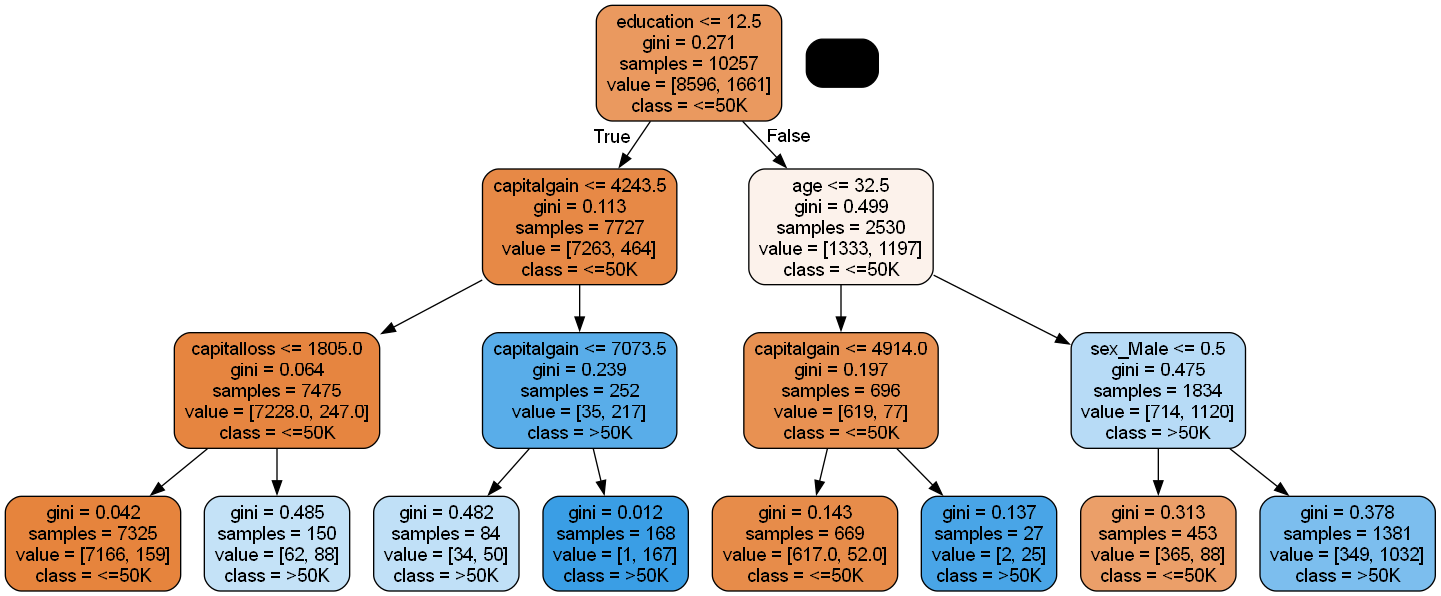

In [14]:
from sklearn import tree
import pydotplus
from IPython.display import Image

# visualize the decision tree
dot_data = tree.export_graphviz(clf2[3], out_file=None, 
                                feature_names=encoded_pred_atts, # attributes names
                                class_names=[v for _, v in sorted(df_code.decode[target].items())], # class labels
                                filled=True, rounded=True)  
graph = pydotplus.graph_from_dot_data(dot_data)  
Image(graph.create_png())

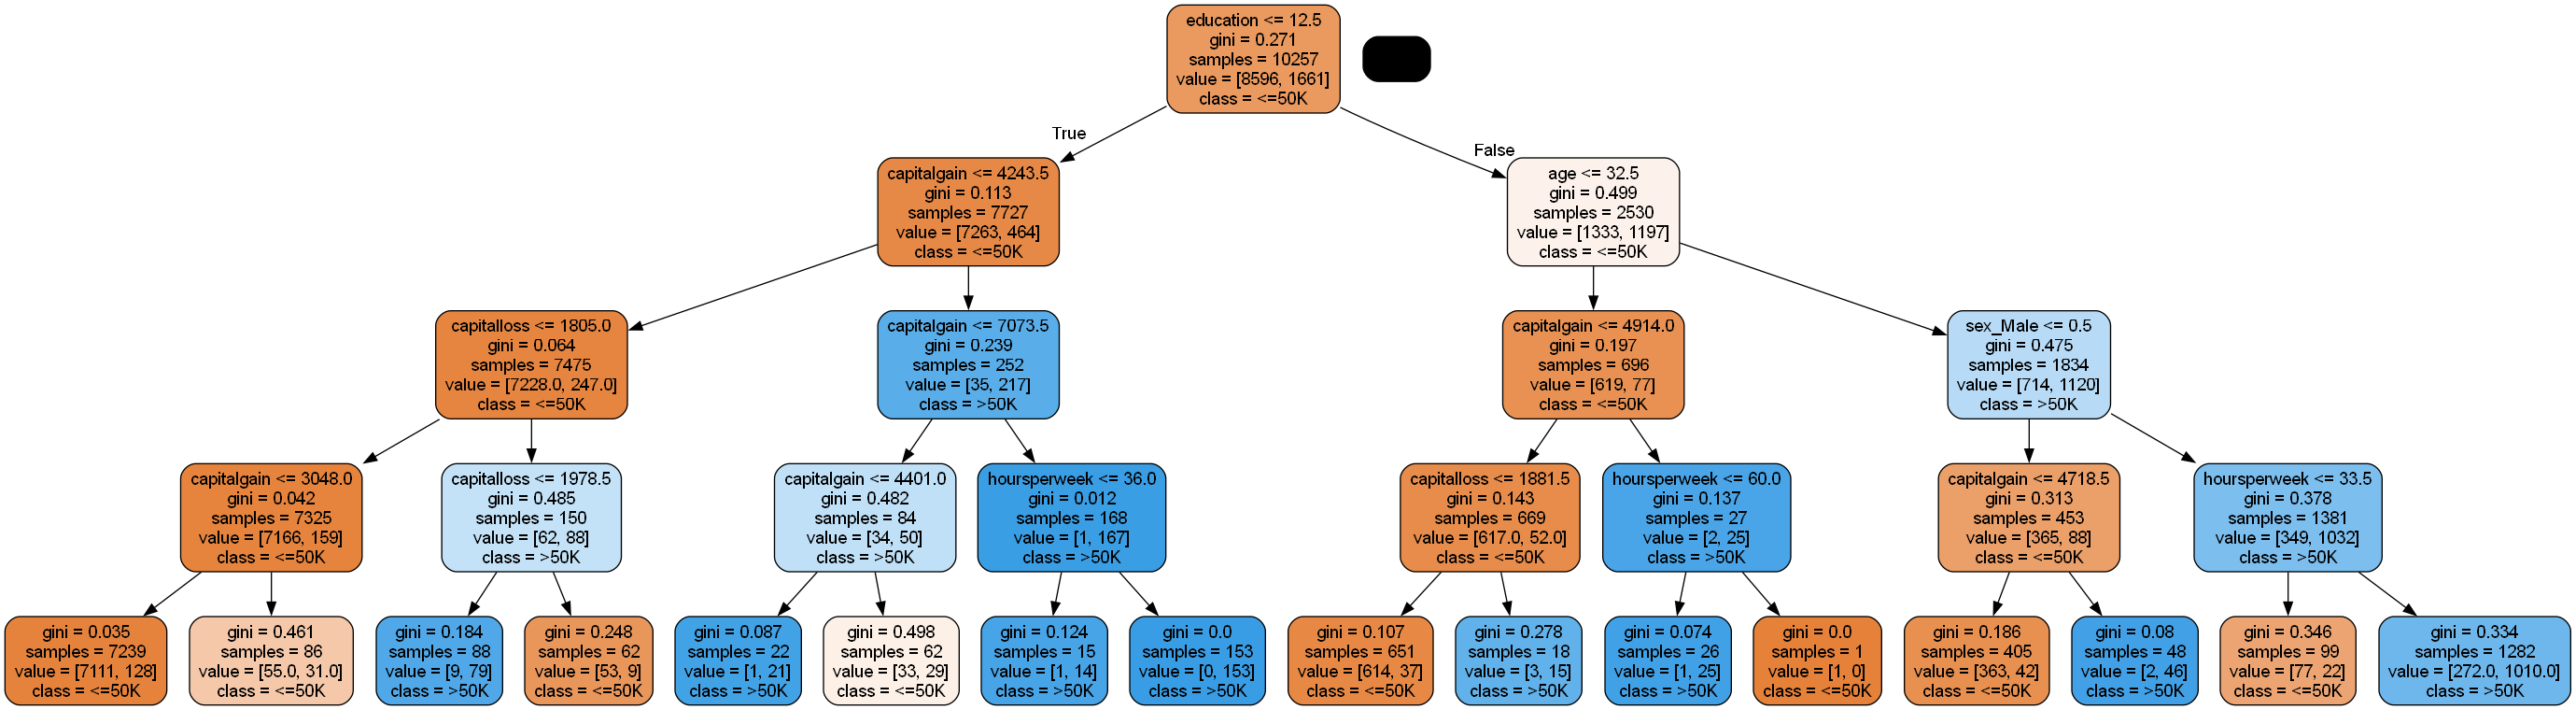

In [15]:
# visualize the decision tree
dot_data = tree.export_graphviz(clf2[4], out_file=None, 
                                feature_names=encoded_pred_atts, # attributes names
                                class_names=[v for _, v in sorted(df_code.decode[target].items())], # class labels
                                filled=True, rounded=True)  
graph = pydotplus.graph_from_dot_data(dot_data)  
Image(graph.create_png())